In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf 


#Regression

In [ ]:
#Load dataset (50 samples)
x = np.random.rand(50)
y = 2 * x + 1 + np.random.randn(50) * 0.1

#Convert 1D array to 2D
x = np.expand_dims(x, axis=1)
y = np.expand_dims(y, axis=1)

print(f"The shape of the input x is : {x.shape}")
print(f"The shape of the input y is : {y.shape}")


In [ ]:
#plot the dataset
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset")
plt.show()

In [ ]:
#Split the dataset 
#Get 60% of dataset as the traiing set, Put the remaining 0% in temorary in temporary variables.

x_train,x_, y_train, y_ = train_test_split(x,y, test_size=0.40, random_state=1)

#Split the 40% subset into two: one half for cross validation and other for testing
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

#Delete temporary variables
del x_, y_

print(f"Shape of training set (input) is:{x_train.shape}") 
print(f"Shape of training set (target) is:{y_train.shape}")
print(f"Shape of cross validation set (input) is:{x_cv.shape}")
print(f"Shape of cross validation set (target) is:{y_cv.shape}")
print(f"Shape of test set (input) is:{x_test.shape}")
print(f"Shape of test set (target) is:{y_test.shape}")

In [ ]:
#Plot the training set, cross validation set and test set
plt.scatter(x_train, y_train, color='blue', label='Training Set')
plt.scatter(x_cv, y_cv, color='orange', label='Cross Validation Set')
plt.scatter(x_test, y_test, color='green', label='Test Set')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dataset Split')
plt.legend()
plt.show()

In [ ]:
#Initialize the class
scaler_linear = StandardScaler()

#Compute the mean and standard deviation of training set then transform it
x_train_sclaed = scaler_linear.fit_transform(x_train)

print(f"Compute mean of the training set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Compute standard deviatio  of the training set:{scaler_linear.scale_.squeeze():.2f}")

#Plot the results
plt.scatter(x_train_sclaed, y_train, color='red')
plt.xlabel("x")
plt.ylabel('y')
plt.title("Scaled input vs target")
plt.show()


In [ ]:
#Train the model
linear_model = LinearRegression()

linear_model.fit(x_train_sclaed, y_train)

In [ ]:
#Evaluate model
yhat = linear_model.predict(x_train_sclaed)

print(f"Training MSE(using sklearn function): {mean_squared_error(y_train, yhat)/2}")

total_squared_error = 0

for i in range(len(yhat)):
    squared_error_i = (yhat[i] - y_train[i])**2
    total_squared_error += squared_error_i
    
mse = total_squared_error / (2*len(yhat))
print(f"training MSE (for loop implementation):{mse.squeeze()}")    

In [ ]:
#Scale the cross validation set using the mean and standard deviation of the training set
x_cv_scaled = scaler_linear.transform(x_cv)

print(f"Mean used to sclae the cv set:{scaler_linear.mean_.squeeze():.2f}")
print(f"Standar deviation used to sclae the cv set:{scaler_linear.scale_.squeeze():.2f}")

#Feed scaled cross validation set
yhat = linear_model.predict(x_cv_scaled)

#Mean squared error
print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat)/2}")

In [ ]:
#Adding polynomial features

poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_mapped = poly.fit_transform(x_train)

print(x_train_mapped[:5])

In [ ]:
#Instantiate the class
scaler_poly = StandardScaler()

x_train_mapped_sclaed = scaler_poly.fit_transform(x_train_mapped)

print(x_train_mapped_sclaed[:5])

In [ ]:
#Initialize the class
model = LinearRegression()

#Train
model.fit(x_train_mapped_sclaed, y_train)

#compute mse
yhat = model.predict(x_train_mapped_sclaed)
print(f"Training MSE:{mean_squared_error(y_train, yhat)/2}")

#Add polynomial features to cross validation
x_cv_mapped = poly.transform(x_cv)

#Scale cross validai=tion set using mean & std of training set
x_cv_mapped_scaled = scaler_poly.transform(x_cv_mapped)

#Compute cross validation mse
yhat = model.predict(x_cv_mapped_scaled)
print(f"Cross Validation MSE:{mean_squared_error(y_cv,yhat)/2}")

In [ ]:
#Initialize lists to save errors, models, and features transforms
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

#loop over polynomial degrees from 1 to 10
for degree in range(1,11):
    #Add polynomial features to training set
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    x_train_mapped = poly.fit_transform(x_train)
    polys.append(poly)
    
    #Scale the training set
    scaler = StandardScaler()
    x_train_mapped_scaled = scaler.fit_transform(x_train_mapped)
    scalers.append(scaler)

    
    #Train the model
    model = LinearRegression()
    model.fit(x_train_mapped_scaled, y_train)
    models.append(model)
    
    #Compute training MSE
    yhat_train = model.predict(x_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat_train)/2
    train_mses.append(train_mse)
    
    #Add polynomial features to cross validation set
    x_cv_mapped = poly.transform(x_cv)
    x_cv_mapped_scaled = scaler.transform(x_cv_mapped)
     
    #Compute cross validation MSE
    yhat_cv = model.predict(x_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat_cv)/2
    cv_mses.append(cv_mse)
    
#Plot training and cross validation MSE vs polynomial degree
plt.plot(range(1,11), train_mses, marker='o', label='Training MSE')
plt.plot(range(1,11), cv_mses, marker='o', label='Cross Validation MSE')
plt.xlabel('Polynomial Degree') 
plt.ylabel('MSE')
plt.title('MSE vs Polynomial Degree')
plt.xticks(range(1,11))
plt.legend()
plt.show()

In [ ]:
degree = np.argmin(cv_mses) + 1
print(f"Optimal polynomial degree: {degree}")

In [ ]:
#Add polynomial features to test set using the optimal degree
optimal_poly = polys[degree-1].transform(x_test)

x_test_mapped_scaled = scalers[degree-1].transform(optimal_poly)

yhat = models[degree-1].predict(x_test_mapped_scaled)

print(f"Training MSE: {train_mses[degree-1]}")
print(f"Cross Validation MSE: {cv_mses[degree-1]}")
print(f"Test MSE: {mean_squared_error(y_test, yhat)/2}")


#Neural Networks (Classification)

In [46]:
#load the classification dataset (200 samples)
x = np.random.rand(200, 1)
y = (x[:, 0] > 0.5).astype(int)


#covert 1D array to 2D
y = np.expand_dims(y, axis=1)

print(f"The shape of the input x is : {x.shape}")
print(f"The shape of the input y is : {y.shape}")

The shape of the input x is : (200, 1)
The shape of the input y is : (200, 1)


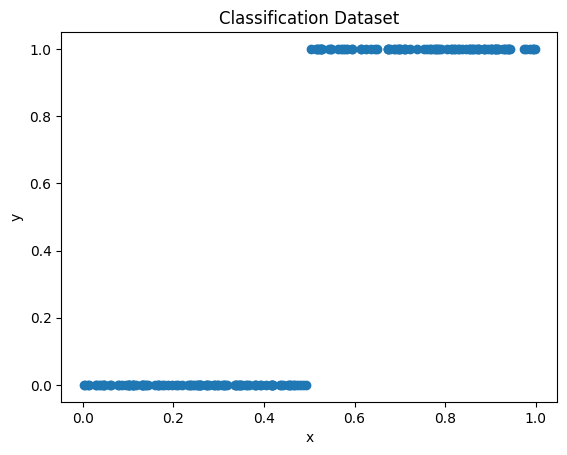

In [47]:
#plot the dataset
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Classification Dataset")
plt.show()

In [48]:
#Split the dataset into training set(60%), cross validation set(20%) and test set(20%)
x_train,x_, y_train, y_ = train_test_split(x,y, test_size=0.40, random_state=1) 
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)
del x_, y_

print(f"Shape of training set (input) is:{x_train.shape}")
print(f"Shape of training set (target) is:{y_train.shape}")
print(f"Shape of cross validation set (input) is:{x_cv.shape}")
print(f"Shape of cross validation set (target) is:{y_cv.shape}")
print(f"Shape of test set (input) is:{x_test.shape}")
print(f"Shape of test set (target) is:{y_test.shape}")

Shape of training set (input) is:(120, 1)
Shape of training set (target) is:(120, 1)
Shape of cross validation set (input) is:(40, 1)
Shape of cross validation set (target) is:(40, 1)
Shape of test set (input) is:(40, 1)
Shape of test set (target) is:(40, 1)


In [49]:
#Sclae the features
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_cv_scaled = scaler.transform(x_cv)
x_test_scaled = scaler.transform(x_test)

In [50]:
#Evaluating the error for classification models

#sampel model output
probabilities = np.array([[0.1], [0.4], [0.6], [0.8]])

#Apply threshold of 0.5 to get predicted labels
predicted_labels = (probabilities >= 0.5).astype(int)

#ground truth labels
true_labels = np.array([[0], [0], [1], [1]])

misclassified = 0

for i in range(len(predicted_labels)):
    if predicted_labels[i] != true_labels[i]:
        misclassified += 1

print(f"probabilities:\n{probabilities.squeeze()}")
print(f"predicted_labels:\n{predicted_labels.squeeze()}")
print(f"true_labels:\n{true_labels.squeeze()}")
print(f"Number of misclassified samples: {misclassified}")
print(f"Accuracy: {1 - misclassified/len(true_labels)}")


probabilities:
[0.1 0.4 0.6 0.8]
predicted_labels:
[0 0 1 1]
true_labels:
[0 0 1 1]
Number of misclassified samples: 0
Accuracy: 1.0


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [58]:
This is one of those annoying TensorFlow state bugs — your code logic is now mostly correct, but the session/graph has become polluted from previous runs.

Let’s fix it cleanly.

💥 1️⃣ Why you STILL get this error

Error:

'Model_<Sequential name=sequential, built=True>_..._kernel_momentum'
is not a valid scope name

👉 This happens because:

You previously created many models in loops
TensorFlow kept old graph/state internally
Now it is trying to reuse corrupted names like:
<Sequential name=...>  ❌ (invalid characters)
✅ 2️⃣ FIX (100% works)
👉 Add this at the TOP of your code:
import tensorflow as tf
tf.keras.backend.clear_session()
✅ 3️⃣ FULL CLEAN VERSION (recommended)
import tensorflow as tf
tf.keras.backend.clear_session()   # 🔥 IMPORTANT

nn_train_error = []
nn_cv_error = []

# Create model ONCE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')

# Train over epochs
for epoch in range(100):
    
    model.fit(x_train_scaled, y_train, epochs=1, batch_size=16, verbose=0)
    
    train_loss = model.evaluate(x_train_scaled, y_train, verbose=0)
    nn_train_error.append(train_loss)
    
    cv_loss = model.evaluate(x_cv_scaled, y_cv, verbose=0)
    nn_cv_error.append(cv_loss)

# Print results
for epoch in range(100):
    print(f"Epoch {epoch+1}: Training Loss = {nn_train_error[epoch]:.4f}, Cross Validation Loss = {nn_cv_error[epoch]:.4f}")

SyntaxError: invalid character '—' (U+2014) (707965237.py, line 1)

In [ ]:
#Select the best model based on cross validation MSE
best_epoch = np.argmin(nn_cv_error)

#compute test error using the best model
yhat = model.predict(x_test_scaled)
yhat = tf.math.sigmoid(yhat)
yhat = np.where(yhat >= 0.5, 1, 0)
nn_test_error = np.mean(yhat != y_test)

print(f"Selected model: {best_epoch+1}")
print(f"Training Error of the selected model: {nn_train_error[best_epoch]:.4f}")
print(f"Cross Validation Error of the selected model: {nn_cv_error[best_epoch]:.4f}")
print(f"Test Error of the selected model: {nn_test_error:.4f}")